# WTMM Neural Network Slope Estimator

Train an MLX neural network on synthetic benchmark signals (with known analytical τ(q), h(q), D(q)) to learn robust partition function slope estimation. The network handles noisy, quantized, and short signals better than least-squares regression.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import sys
sys.path.insert(0, '.')

import wtmm
from wtmm.signals import ucantor, tau_equation
from wtmm.datasets import (
    add_white_noise, add_pink_noise, add_brownian_noise,
    quantize, resize_signal, apply_degradation,
    build_degradation_configs, build_pipeline_configs,
    build_training_set, dataset_to_arrays, extract_features,
    adaptive_q_grid, compute_specific_heat, detect_phase_transition,
)
from wtmm.nn_model import SlopeEstimator, compute_loss_with_q
from wtmm.nn_train import (
    train, evaluate, compare_nn_vs_ols, compute_metrics,
    spectrum_width, per_signal_metrics, save_model, load_model,
)

print('Imports OK')

Imports OK


## 1. Build Signal Catalog with Analytical Solutions

We reuse the signal generators from synthetic_signals.ipynb and pair each with its known τ(q), h(q), D(q).

In [7]:
# ----- Signal generators (copied from synthetic_signals.ipynb) -----

def fbm_spectral(N, H, seed=42):
    """Fractional Brownian motion via spectral synthesis."""
    rng = np.random.default_rng(seed)
    freqs = np.fft.rfftfreq(N, d=1.0)
    freqs[0] = 1.0
    power = freqs ** (-(2 * H + 1))
    phases = rng.uniform(0, 2 * np.pi, len(freqs))
    amplitudes = rng.standard_normal(len(freqs))
    spectrum = amplitudes * np.sqrt(power) * np.exp(1j * phases)
    spectrum[0] = 0
    return np.fft.irfft(spectrum, n=N)

def devil_staircase(r, p, N=8192):
    """Devil's staircase = integrated Cantor measure (cumsum of multinomial)."""
    measure, _ = ucantor(N, r, p)
    return np.cumsum(measure)

def lognormal_cascade(N, mu, seed=42):
    """Multiplicative log-normal cascade."""
    rng = np.random.default_rng(seed)
    n_levels = int(np.log2(N))
    signal = np.ones(N)
    for level in range(1, n_levels + 1):
        block = N // (2 ** level)
        for i in range(2 ** level):
            w = np.exp(mu * rng.standard_normal() - mu**2 / 2)
            signal[i * block:(i + 1) * block] *= w
    return signal

print('Signal generators defined')

Signal generators defined


In [8]:
# ----- Build catalog: signals + analytical spectra -----
# Adaptive q grid: fine 0.1 spacing in [-2, 2] for phase transition detection,
# coarse 0.5 in tails

from wtmm.spectra import theoretical_devil_staircase

N = 4096
q = adaptive_q_grid()  # ~47 values
n_q = len(q)
print(f'Adaptive q grid: {n_q} values, range [{q[0]}, {q[-1]}]')
print(f'Fine region: {np.sum((q >= -2) & (q < 2))} points in [-2, 2)')

signals_with_theory = []

# --- Monofractal: fBm (no phase transitions) ---
# fBm is already a function (not a measure), analyzed with g2 (expo=-1):
#   |W[fBm]| ~ a^H, so with expo=-1 normalization:
#   tau(q) = q*H - 1, h(q) = H, D(q) = 1
for H in [0.3, 0.5, 0.7]:
    tau_fbm = q * H - 1
    h_fbm = np.full_like(q, H)
    D_fbm = np.ones_like(q)  # D(h) = 1 for fBm
    signals_with_theory.append({
        'name': f'fBm H={H}',
        'signal': fbm_spectral(N, H),
        'theory': {'tau_q': tau_fbm, 'h_q': h_fbm, 'D_q': D_fbm},
        'q_list': q,
    })

# --- Multifractal: Devil's staircases (integrated Cantor measures) ---
# We integrate the Cantor measure (cumsum) to get a function,
# then use theoretical_devil_staircase which accounts for:
#   h_eff = h_measure + 1 + expo, with expo=-1 -> h_eff = h_measure
cantor_params = [
    ([1/3, 1/3, 1/3], [0.5, 0.0, 0.5]),  # Devil's staircase (symmetric gaps)
    ([1/3, 1/3, 1/3], [0.7, 0.0, 0.3]),  # Asymmetric
    ([0.5, 0.5], [0.7, 0.3]),              # Binomial
    ([0.5, 0.5], [0.6, 0.4]),              # Weak multifractal
]

for r, p in cantor_params:
    # Analytical spectra via theoretical_devil_staircase (handles integration + expo)
    tau_vals, h_vals, D_vals = theoretical_devil_staircase(q, r, p, expo=-1.0)
    
    label = f'Cantor r={[round(x,2) for x in r]} p={[round(x,2) for x in p]}'
    signals_with_theory.append({
        'name': label,
        'signal': devil_staircase(r, p, N),  # integrated measure
        'theory': {'tau_q': tau_vals, 'h_q': h_vals, 'D_q': D_vals},
        'q_list': q,
    })

# --- Multifractal: Log-normal cascade (smooth, no phase transitions) ---
for mu in [0.2, 0.5]:
    tau_ln = -1 + q - mu**2 * q * (q - 1) / 2
    h_ln = 1 - mu**2 * (q - 0.5)
    D_ln = q * h_ln - tau_ln
    signals_with_theory.append({
        'name': f'Log-normal mu={mu}',
        'signal': lognormal_cascade(N, mu),
        'theory': {'tau_q': tau_ln, 'h_q': h_ln, 'D_q': D_ln},
        'q_list': q,
    })

# --- Log-Poisson (HAS phase transition -- D(h)<0 freezing at negative q) ---
for C1, beta in [(0.15, 0.5), (0.25, 0.3)]:
    tau_lp = -C1 * (1 - beta**(q - 1)) / (1 - beta) + (q - 1)
    h_lp = 1 - C1 * np.log(beta) * beta**(q - 1) / (1 - beta)
    D_lp = q * h_lp - tau_lp
    signals_with_theory.append({
        'name': f'Log-Poisson C1={C1} beta={beta}',
        'signal': lognormal_cascade(N, C1),  # approximate generation
        'theory': {'tau_q': tau_lp, 'h_q': h_lp, 'D_q': D_lp},
        'q_list': q,
    })

print(f'\nCatalog: {len(signals_with_theory)} signals')
print(f'{"Signal":45s} {"width(h)":>10s} {"transition?":>12s} {"q*":>8s}')
print('-' * 80)
for s in signals_with_theory:
    w = spectrum_width(s['theory']['h_q'])
    has_t, q_star, C_max = detect_phase_transition(
        s['theory']['tau_q'], q,
        h_q=s['theory']['h_q'], D_q=s['theory']['D_q'])
    t_str = f'YES' if has_t else 'no'
    q_str = f'{q_star:.2f}' if has_t else '-'
    print(f"  {s['name']:43s} {w:10.4f} {t_str:>12s} {q_str:>8s}")

Adaptive q grid: 47 values, range [-3.0, 4.0]
Fine region: 40 points in [-2, 2)

Catalog: 11 signals
Signal                                          width(h)  transition?       q*
--------------------------------------------------------------------------------
  fBm H=0.3                                       0.0000           no        -
  fBm H=0.5                                       0.0000           no        -
  fBm H=0.7                                       0.0000           no        -
  Cantor r=[0.33, 0.33, 0.33] p=[0.5, 0.0, 0.5]     0.0000           no        -
  Cantor r=[0.33, 0.33, 0.33] p=[0.7, 0.0, 0.3]     0.6714           no        -
  Cantor r=[0.5, 0.5] p=[0.7, 0.3]                1.0642           no        -
  Cantor r=[0.5, 0.5] p=[0.6, 0.4]                0.3354           no        -
  Log-normal mu=0.2                               0.2800           no        -
  Log-normal mu=0.5                               1.7500          YES    -2.82
  Log-Poisson C1=0.15 be

## 2. Configure Degradations and Build Dataset

In [9]:
# Degradation grid — start small for testing, expand later
deg_configs = build_degradation_configs(
    noise_types=['none', 'white', 'pink'],
    snrs=[30, 20, 10],
    n_bits_list=[None, 12, 8],
    target_lengths=[None],  # keep original length
)

pipe_configs = build_pipeline_configs(
    wavelets=['g2'],
    n_voices=[10],
    coi_flags=[True],
)

print(f'Degradation configs: {len(deg_configs)}')
print(f'Pipeline configs: {len(pipe_configs)}')
print(f'Total combinations per signal: {len(deg_configs) * len(pipe_configs)}')
print(f'Total dataset size: {len(signals_with_theory) * len(deg_configs) * len(pipe_configs)}')

Degradation configs: 21
Pipeline configs: 1
Total combinations per signal: 21
Total dataset size: 231


In [10]:
# Build the training dataset
# This runs the full WTMM pipeline on each degraded signal

n_oct = 5
n_voice = 10
n_scales = n_oct * n_voice
a_min = 1.0

dataset = build_training_set(
    signals_with_theory,
    degradation_configs=deg_configs,
    pipeline_configs=pipe_configs,
    n_oct=n_oct,
    a_min=a_min,
    q_list=q.tolist(),
    n_q_target=n_q,
    n_scales_target=n_scales,
    log2_a_min=0.0,
    log2_a_max=4.9,
    verbose=True,
)

print(f'\nDataset size: {len(dataset)} samples')

Total extrema: 9142
Total extrema: 9143
Total extrema: 9139
Total extrema: 9129
Total extrema: 9147
Total extrema: 9150
Total extrema: 9184
Total extrema: 9181
Total extrema: 9186
Total extrema: 9512
Total extrema: 9574
Total extrema: 9532
Total extrema: 9157
Total extrema: 9145
Total extrema: 9140
Total extrema: 9137
Total extrema: 9151
Total extrema: 9131
Total extrema: 9269
Total extrema: 9284
Total extrema: 9277
Total extrema: 8699
Total extrema: 8696
Total extrema: 8691
Total extrema: 8731
Total extrema: 8789
Total extrema: 8727
Total extrema: 9075
Total extrema: 9054
Total extrema: 9132
Total extrema: 9901
Total extrema: 9756
Total extrema: 9811
Total extrema: 8757
Total extrema: 8709
Total extrema: 8720
Total extrema: 8985
Total extrema: 8899
Total extrema: 8902
Total extrema: 9313
Total extrema: 9404
Total extrema: 9233
Total extrema: 8237
Total extrema: 8234
Total extrema: 8259
Total extrema: 8631
Total extrema: 8614
Total extrema: 8703
Total extrema: 9372
  [50/231] fBm H=0.7

In [11]:
# Convert to arrays (4 channels: T, H, D, C)
X_curves, X_meta, Y, Y_C, Y_trans, Q_mask, Y_ols = dataset_to_arrays(dataset, n_q, n_scales)
print(f'X_curves: {X_curves.shape}  (4 channels: T, H, D, C)')
print(f'X_meta: {X_meta.shape}')
print(f'Y: {Y.shape}  (tau, h, D)')
print(f'Y_C: {Y_C.shape}  (specific heat)')
print(f'Y_trans: {Y_trans.shape}  (has_transition, q_star)')
print(f'Q_mask: {Q_mask.shape}  (valid q fraction: {Q_mask.mean():.2%})')
if Y_ols is not None:
    print(f'Y_ols: {Y_ols.shape}')

# Show transition label distribution
n_trans = int(Y_trans[:, 0].sum())
print(f'\nSamples with phase transitions: {n_trans}/{len(dataset)}')

X_curves: (231, 4, 47, 50)  (4 channels: T, H, D, C)
X_meta: (231, 13)
Y: (231, 3, 47)  (tau, h, D)
Y_C: (231, 47)  (specific heat)
Y_trans: (231, 2)  (has_transition, q_star)
Q_mask: (231, 47)  (valid q fraction: 100.00%)
Y_ols: (231, 3, 47)

Samples with phase transitions: 63/231


## 3. Visualize Dataset

Inspect partition function curves and labels before training.

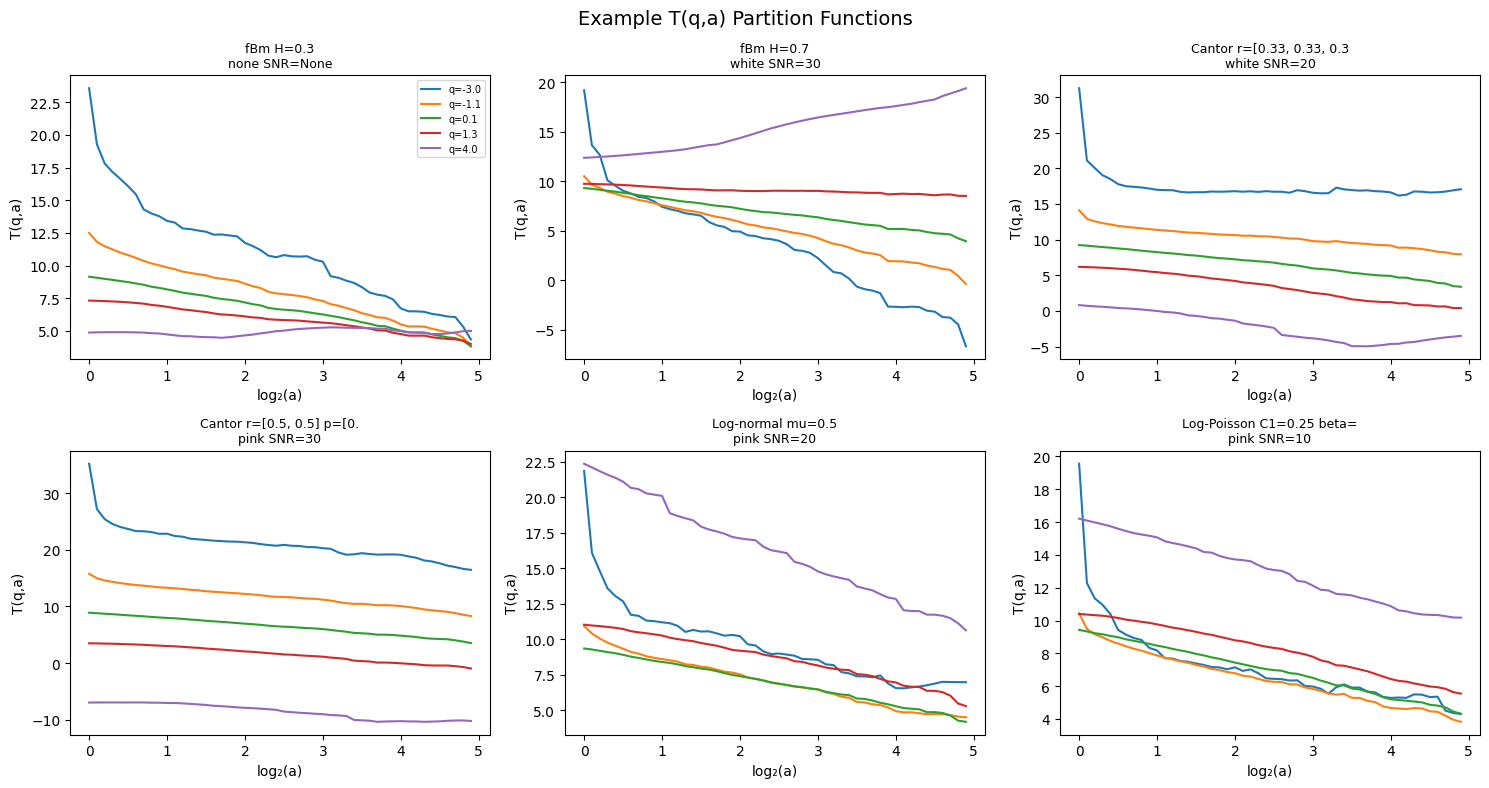

In [12]:
# Show a few example partition function curves
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Pick 6 samples spanning different signals and degradations
sample_indices = np.linspace(0, len(dataset)-1, 6, dtype=int)

for ax_idx, si in enumerate(sample_indices):
    row, col = divmod(ax_idx, 3)
    ax = axes[row, col]
    sample = dataset[si]
    
    T = sample['features']['T_curves']
    log2_a = sample['features']['log2_a']
    
    for qi in [0, n_q//4, n_q//2, 3*n_q//4, n_q-1]:
        if qi < T.shape[0]:
            ax.plot(log2_a[:T.shape[1]], T[qi, :], 
                    label=f'q={q[qi]:.1f}')
    
    info = sample['info']
    ax.set_title(f"{info['signal_name'][:25]}\n"
                 f"{info['degradation']['noise_type']} "
                 f"SNR={info['degradation']['snr_db']}",
                 fontsize=9)
    ax.set_xlabel('log₂(a)')
    ax.set_ylabel('T(q,a)')
    if ax_idx == 0:
        ax.legend(fontsize=7)

plt.suptitle('Example T(q,a) Partition Functions', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Train the Network

In [13]:
# Train
model, history = train(
    dataset,
    n_q=n_q,
    n_scales=n_scales,
    q_array=q.astype(np.float32),
    epochs=200,
    lr=1e-3,
    batch_size=32,
    val_fraction=0.2,
    patience=30,
    consistency_weight=0.1,
    width_weight=0.1,
    hidden_dim=256,
    n_conv_channels=32,
    verbose=True,
)

Epoch   0 | train=66.250144 val=79.036463 | MAE h=0.9216 D=1.8999 width=6.4698
Epoch  10 | train=63.264035 val=66.901518 | MAE h=0.9030 D=1.8549 width=7.6460
Epoch  20 | train=2.222944 val=0.897582 | MAE h=0.3401 D=0.4635 width=0.8662
Epoch  30 | train=1.453998 val=1.749578 | MAE h=0.3167 D=0.4725 width=0.9818
Epoch  40 | train=1.212093 val=0.571803 | MAE h=0.2357 D=0.3546 width=0.5632
Epoch  50 | train=2.910267 val=0.669078 | MAE h=0.2420 D=0.3386 width=0.8513
Epoch  60 | train=1.247929 val=1.560657 | MAE h=0.2617 D=0.3557 width=0.8137
Epoch  70 | train=1.416137 val=0.881519 | MAE h=0.2340 D=0.2999 width=0.4869
Epoch  80 | train=0.534671 val=0.570930 | MAE h=0.2081 D=0.2576 width=0.5190
Epoch  90 | train=2.619078 val=0.270062 | MAE h=0.2040 D=0.2271 width=0.4966
Epoch 100 | train=0.940262 val=0.823540 | MAE h=0.2441 D=0.2960 width=0.3778
Epoch 110 | train=0.758078 val=0.767970 | MAE h=0.2118 D=0.2613 width=0.5837
Epoch 120 | train=1.071113 val=0.719868 | MAE h=0.2059 D=0.2365 width=0.

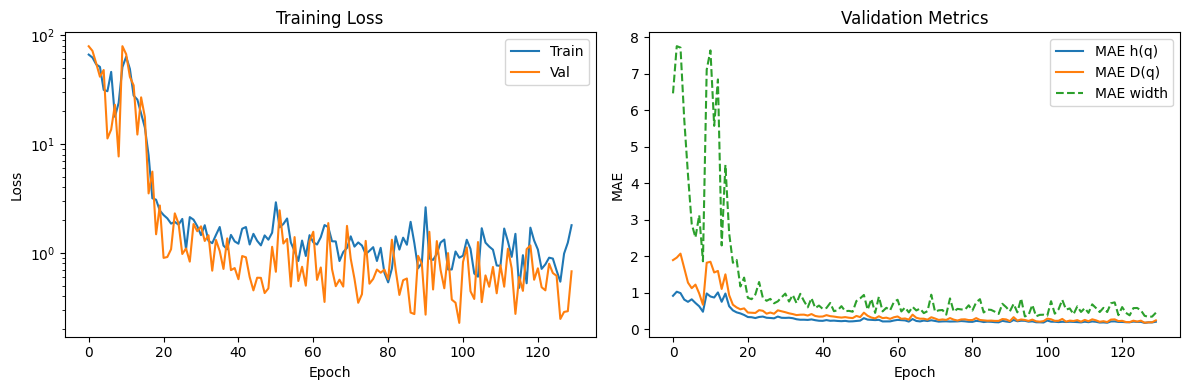

In [14]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_yscale('log')
ax1.legend()
ax1.set_title('Training Loss')

mae_h = [m['mae_h'] for m in history['val_metrics']]
mae_D = [m['mae_D'] for m in history['val_metrics']]
mae_w = [m['width_mae'] for m in history['val_metrics']]
ax2.plot(mae_h, label='MAE h(q)')
ax2.plot(mae_D, label='MAE D(q)')
ax2.plot(mae_w, label='MAE width', linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.set_title('Validation Metrics')

plt.tight_layout()
plt.show()

## 5. Evaluation: NN vs OLS vs Theory

In [15]:
# Full evaluation
results = evaluate(model, dataset, n_q, n_scales, q)

print('=== Overall Metrics ===')
for k, v in results['metrics'].items():
    if isinstance(v, float):
        print(f'  {k:15s}: {v:.6f}')

if results['ols_metrics'] is not None:
    print('\n=== OLS Baseline ===')
    for k, v in results['ols_metrics'].items():
        if isinstance(v, float):
            print(f'  {k:15s}: {v:.6f}')

=== Overall Metrics ===
  mse_tau        : 0.163985
  mae_tau        : 0.255890
  mse_h          : 0.103712
  mae_h          : 0.179070
  mse_D          : 0.271615
  mae_D          : 0.241285
  mse_total      : 0.539313
  width_mae      : 0.401199
  width_bias     : 0.128045
  transition_accuracy: 0.995671
  q_star_mae     : 0.075601

=== OLS Baseline ===
  mse_tau        : 6.764469
  mae_tau        : 1.109717
  mse_h          : 10.800050
  mae_h          : 1.157638
  mse_D          : 111.874847
  mae_D          : 1.445634
  mse_total      : 129.439346
  width_mae      : 5.345788
  width_bias     : -4.998996


In [16]:
# Per-signal breakdown
print('=== Per-Signal MAE ===')
print(f'{"Signal":45s} {"MAE h":>8s} {"MAE D":>8s} {"MAE τ":>8s} {"Width MAE":>10s}')
print('-' * 85)
for name, met in sorted(results['per_signal'].items()):
    print(f"{name:45s} {met['mae_h']:8.4f} {met['mae_D']:8.4f} "
          f"{met['mae_tau']:8.4f} {met['width_mae']:10.4f}")

=== Per-Signal MAE ===
Signal                                           MAE h    MAE D    MAE τ  Width MAE
-------------------------------------------------------------------------------------
Cantor r=[0.33, 0.33, 0.33] p=[0.5, 0.0, 0.5]   0.1550   0.2419   0.3690     0.4747
Cantor r=[0.33, 0.33, 0.33] p=[0.7, 0.0, 0.3]   0.1271   0.3616   0.2635     0.2195
Cantor r=[0.5, 0.5] p=[0.6, 0.4]                0.2439   0.1103   0.2873     0.2022
Cantor r=[0.5, 0.5] p=[0.7, 0.3]                0.3249   0.1344   0.3387     0.5863
Log-Poisson C1=0.15 beta=0.5                    0.1107   0.2272   0.0922     0.4157
Log-Poisson C1=0.25 beta=0.3                    0.3505   0.6810   0.3951     1.4679
Log-normal mu=0.2                               0.0738   0.2894   0.1992     0.1878
Log-normal mu=0.5                               0.0752   0.1080   0.0661     0.1367
fBm H=0.3                                       0.3601   0.1788   0.5119     0.2735
fBm H=0.5                                       0.1

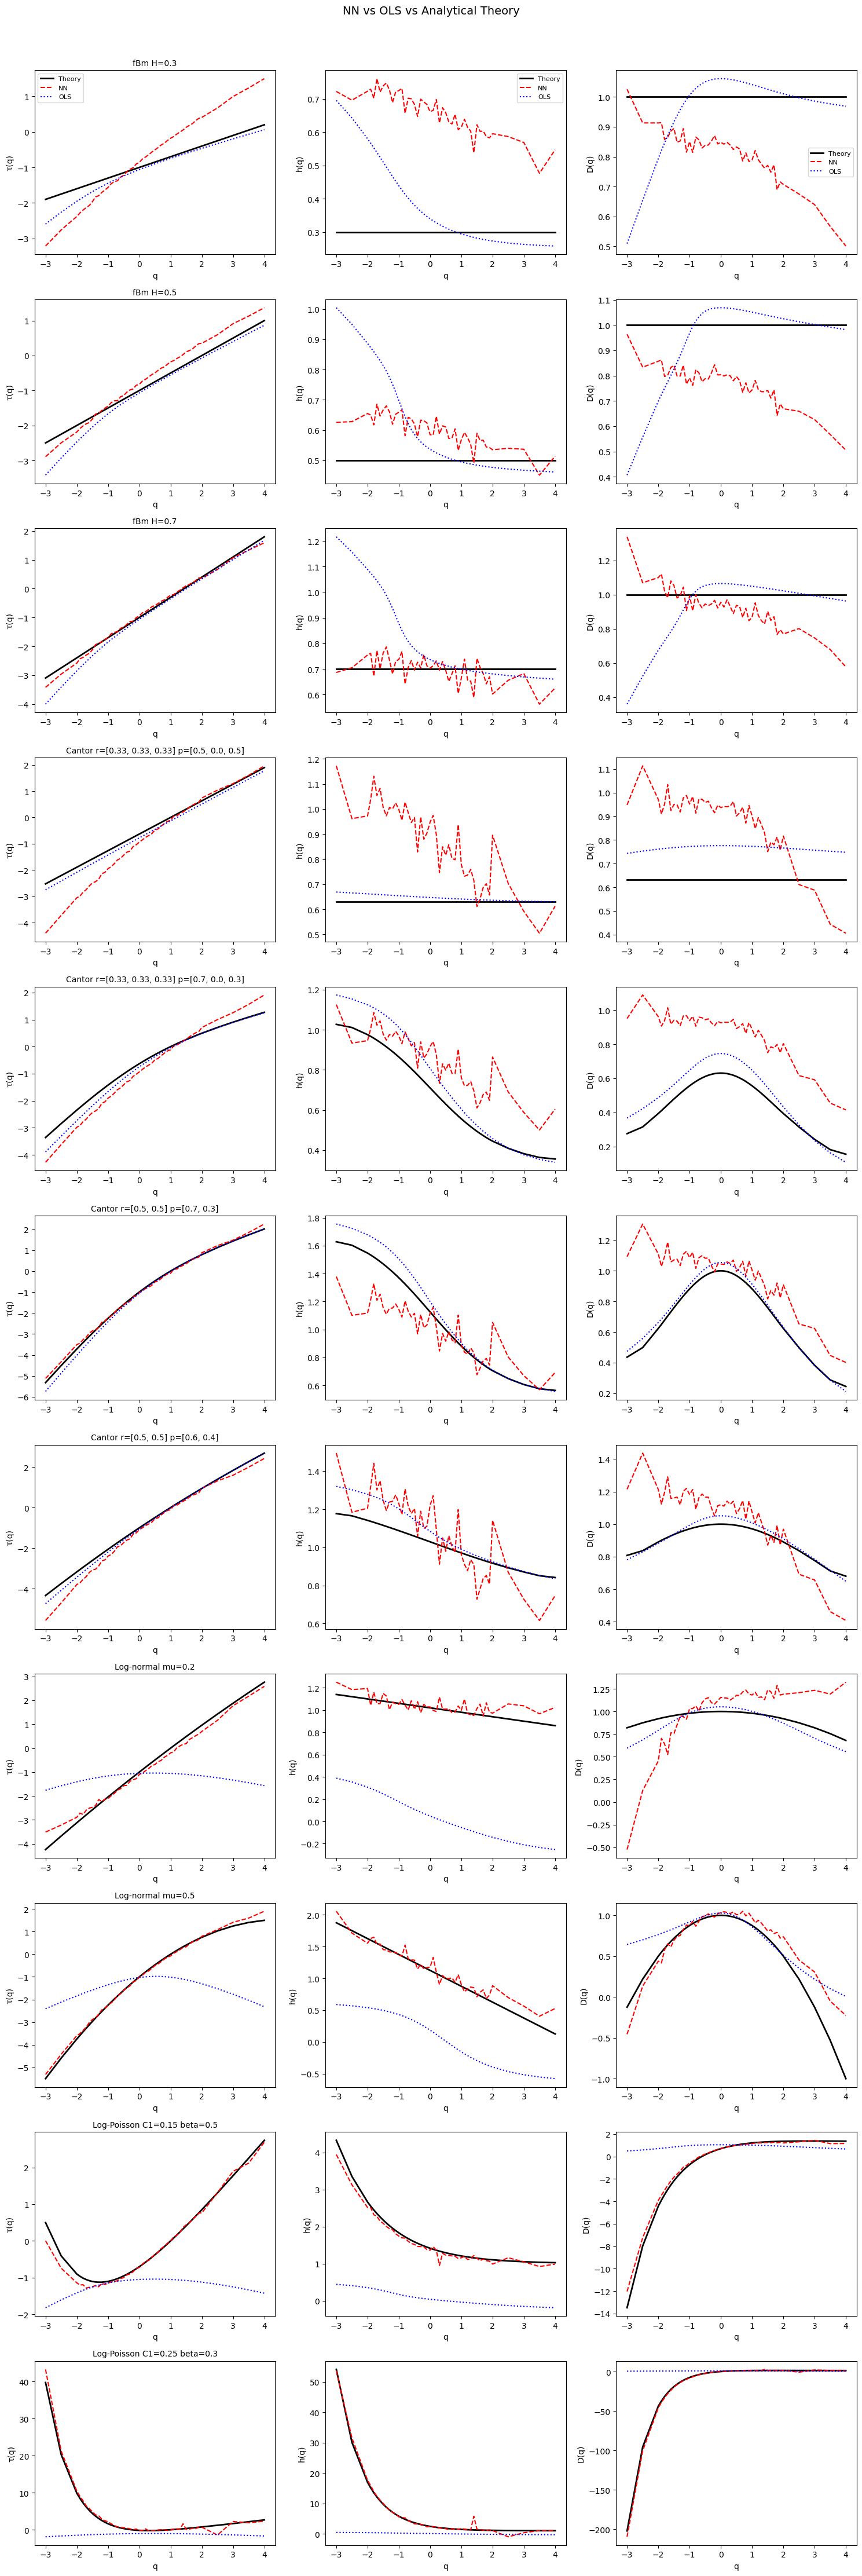

In [17]:
# Compare NN vs OLS vs Theory — spectra plots
comp = compare_nn_vs_ols(dataset, results['predictions'], q)

# Pick one sample per signal type for visualization
seen = set()
plot_indices = []
for i, sample in enumerate(dataset):
    name = sample['info']['signal_name']
    # Pick the clean (no degradation) version
    if name not in seen and sample['info']['degradation']['noise_type'] == 'none' \
       and sample['info']['degradation']['n_bits'] is None:
        seen.add(name)
        plot_indices.append(i)

n_plot = len(plot_indices)
fig, axes = plt.subplots(n_plot, 3, figsize=(15, 4 * n_plot))
if n_plot == 1:
    axes = axes[np.newaxis, :]

for row, idx in enumerate(plot_indices):
    name = comp['signal_names'][idx]
    
    for col, (spec_name, spec_idx) in enumerate(
            [('τ(q)', 0), ('h(q)', 1), ('D(q)', 2)]):
        ax = axes[row, col]
        ax.plot(q, comp['true'][idx, spec_idx], 'k-', lw=2, label='Theory')
        ax.plot(q, comp['nn'][idx, spec_idx], 'r--', lw=1.5, label='NN')
        if comp['ols'] is not None:
            ax.plot(q, comp['ols'][idx, spec_idx], 'b:', lw=1.5, label='OLS')
        ax.set_xlabel('q')
        ax.set_ylabel(spec_name)
        if col == 0:
            ax.set_title(f'{name}', fontsize=10)
        if row == 0:
            ax.legend(fontsize=8)

plt.suptitle('NN vs OLS vs Analytical Theory', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Accuracy vs Noise Level (SNR Sweep)

In [18]:
# Group by SNR
from collections import defaultdict

snr_groups = defaultdict(lambda: {'nn': [], 'ols': [], 'true': []})

for i, sample in enumerate(dataset):
    snr = sample['info']['degradation']['snr_db']
    noise = sample['info']['degradation']['noise_type']
    if noise == 'none':
        snr_key = 'clean'
    else:
        snr_key = f'{noise} {snr}dB'
    
    snr_groups[snr_key]['nn'].append(results['predictions'][i])
    snr_groups[snr_key]['true'].append(
        np.stack([sample['labels']['tau_q'],
                  sample['labels']['h_q'],
                  sample['labels']['D_q']]))
    if sample['ols'] is not None:
        snr_groups[snr_key]['ols'].append(
            np.stack([sample['ols']['tau_q'],
                      sample['ols']['h_q'],
                      sample['ols']['D_q']]))

print(f'{"Condition":25s} {"NN MAE h":>10s} {"OLS MAE h":>10s} '
      f'{"NN width":>10s} {"OLS width":>10s}')
print('-' * 70)
for key in sorted(snr_groups.keys()):
    grp = snr_groups[key]
    nn_arr = np.array(grp['nn'])
    true_arr = np.array(grp['true'])
    nn_met = compute_metrics(nn_arr, true_arr)
    
    ols_str_h = 'N/A'
    ols_str_w = 'N/A'
    if len(grp['ols']) > 0:
        ols_arr = np.array(grp['ols'])
        ols_met = compute_metrics(ols_arr, true_arr)
        ols_str_h = f"{ols_met['mae_h']:.4f}"
        ols_str_w = f"{ols_met['width_mae']:.4f}"
    
    print(f"{key:25s} {nn_met['mae_h']:10.4f} {ols_str_h:>10s} "
          f"{nn_met['width_mae']:10.4f} {ols_str_w:>10s}")

Condition                   NN MAE h  OLS MAE h   NN width  OLS width
----------------------------------------------------------------------
clean                         0.1559     0.8981     0.3786     5.2793
pink 10dB                     0.2033     1.1812     0.5155     5.3869
pink 20dB                     0.1829     1.1386     0.3778     5.3525
pink 30dB                     0.1694     1.0866     0.3245     5.3437
white 10dB                    0.1943     1.3735     0.4639     5.3849
white 20dB                    0.1793     1.2585     0.3718     5.3552
white 30dB                    0.1684     1.1670     0.3763     5.3180


## 7. Accuracy vs Quantization (Bit Depth Sweep)

In [19]:
bits_groups = defaultdict(lambda: {'nn': [], 'ols': [], 'true': []})

for i, sample in enumerate(dataset):
    bits = sample['info']['degradation']['n_bits']
    bits_key = f'{bits} bits' if bits is not None else 'no quantization'
    
    bits_groups[bits_key]['nn'].append(results['predictions'][i])
    bits_groups[bits_key]['true'].append(
        np.stack([sample['labels']['tau_q'],
                  sample['labels']['h_q'],
                  sample['labels']['D_q']]))
    if sample['ols'] is not None:
        bits_groups[bits_key]['ols'].append(
            np.stack([sample['ols']['tau_q'],
                      sample['ols']['h_q'],
                      sample['ols']['D_q']]))

print(f'{"Quantization":20s} {"NN MAE h":>10s} {"OLS MAE h":>10s} '
      f'{"NN width":>10s} {"OLS width":>10s}')
print('-' * 60)
for key in sorted(bits_groups.keys()):
    grp = bits_groups[key]
    nn_arr = np.array(grp['nn'])
    true_arr = np.array(grp['true'])
    nn_met = compute_metrics(nn_arr, true_arr)
    
    ols_str_h = 'N/A'
    ols_str_w = 'N/A'
    if len(grp['ols']) > 0:
        ols_arr = np.array(grp['ols'])
        ols_met = compute_metrics(ols_arr, true_arr)
        ols_str_h = f"{ols_met['mae_h']:.4f}"
        ols_str_w = f"{ols_met['width_mae']:.4f}"
    
    print(f"{key:20s} {nn_met['mae_h']:10.4f} {ols_str_h:>10s} "
          f"{nn_met['width_mae']:10.4f} {ols_str_w:>10s}")

Quantization           NN MAE h  OLS MAE h   NN width  OLS width
------------------------------------------------------------
12 bits                  0.1787     1.1550     0.4036     5.3338
8 bits                   0.1789     1.1636     0.3774     5.3648
no quantization          0.1796     1.1544     0.4227     5.3388


## 8. D(h) Spectra Comparison

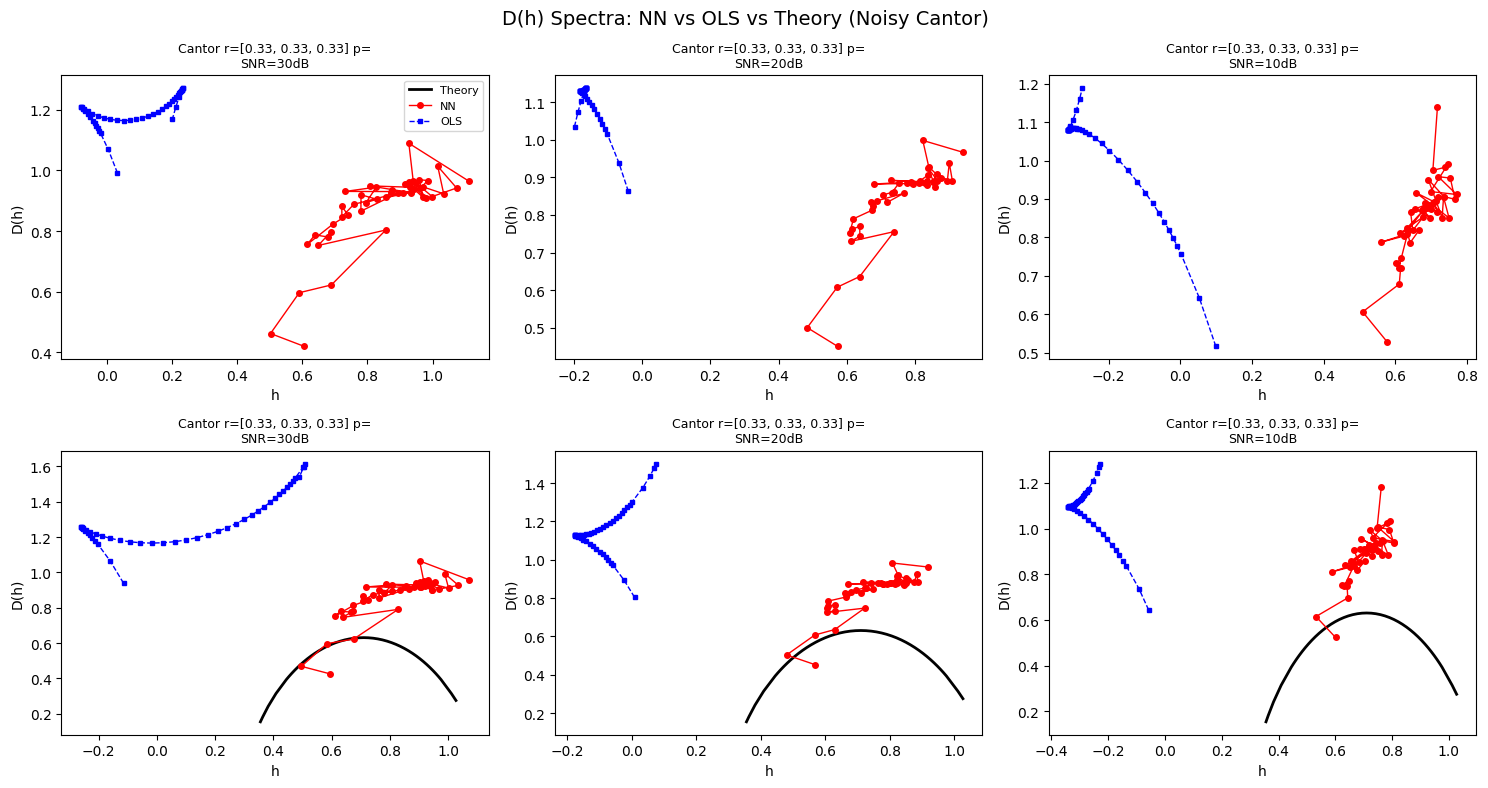

In [20]:
# D(h) spectra: NN vs OLS vs Theory for noisy Cantor examples
# Find Cantor samples at different noise levels
cantor_noisy = []
for i, sample in enumerate(dataset):
    if 'Cantor' in sample['info']['signal_name'] and \
       sample['info']['degradation']['noise_type'] == 'white' and \
       sample['info']['degradation']['n_bits'] is None:
        cantor_noisy.append(i)

if len(cantor_noisy) > 0:
    n_show = min(6, len(cantor_noisy))
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    for ax_idx in range(n_show):
        row, col = divmod(ax_idx, 3)
        ax = axes[row, col]
        idx = cantor_noisy[ax_idx]
        sample = dataset[idx]
        
        # Theory D(h)
        h_true = sample['labels']['h_q']
        D_true = sample['labels']['D_q']
        ax.plot(h_true, D_true, 'k-', lw=2, label='Theory')
        
        # NN D(h)
        h_nn = results['predictions'][idx, 1]
        D_nn = results['predictions'][idx, 2]
        ax.plot(h_nn, D_nn, 'ro-', ms=4, lw=1, label='NN')
        
        # OLS D(h)
        if sample['ols'] is not None:
            h_ols = sample['ols']['h_q']
            D_ols = sample['ols']['D_q']
            ax.plot(h_ols, D_ols, 'bs--', ms=3, lw=1, label='OLS')
        
        snr = sample['info']['degradation']['snr_db']
        name = sample['info']['signal_name'][:30]
        ax.set_title(f'{name}\nSNR={snr}dB', fontsize=9)
        ax.set_xlabel('h')
        ax.set_ylabel('D(h)')
        if ax_idx == 0:
            ax.legend(fontsize=8)
    
    # Hide empty subplots
    for ax_idx in range(n_show, 6):
        row, col = divmod(ax_idx, 3)
        axes[row, col].set_visible(False)
    
    plt.suptitle('D(h) Spectra: NN vs OLS vs Theory (Noisy Cantor)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No noisy Cantor samples found')

## 8b. Specific Heat C(q) and Phase Transition Detection

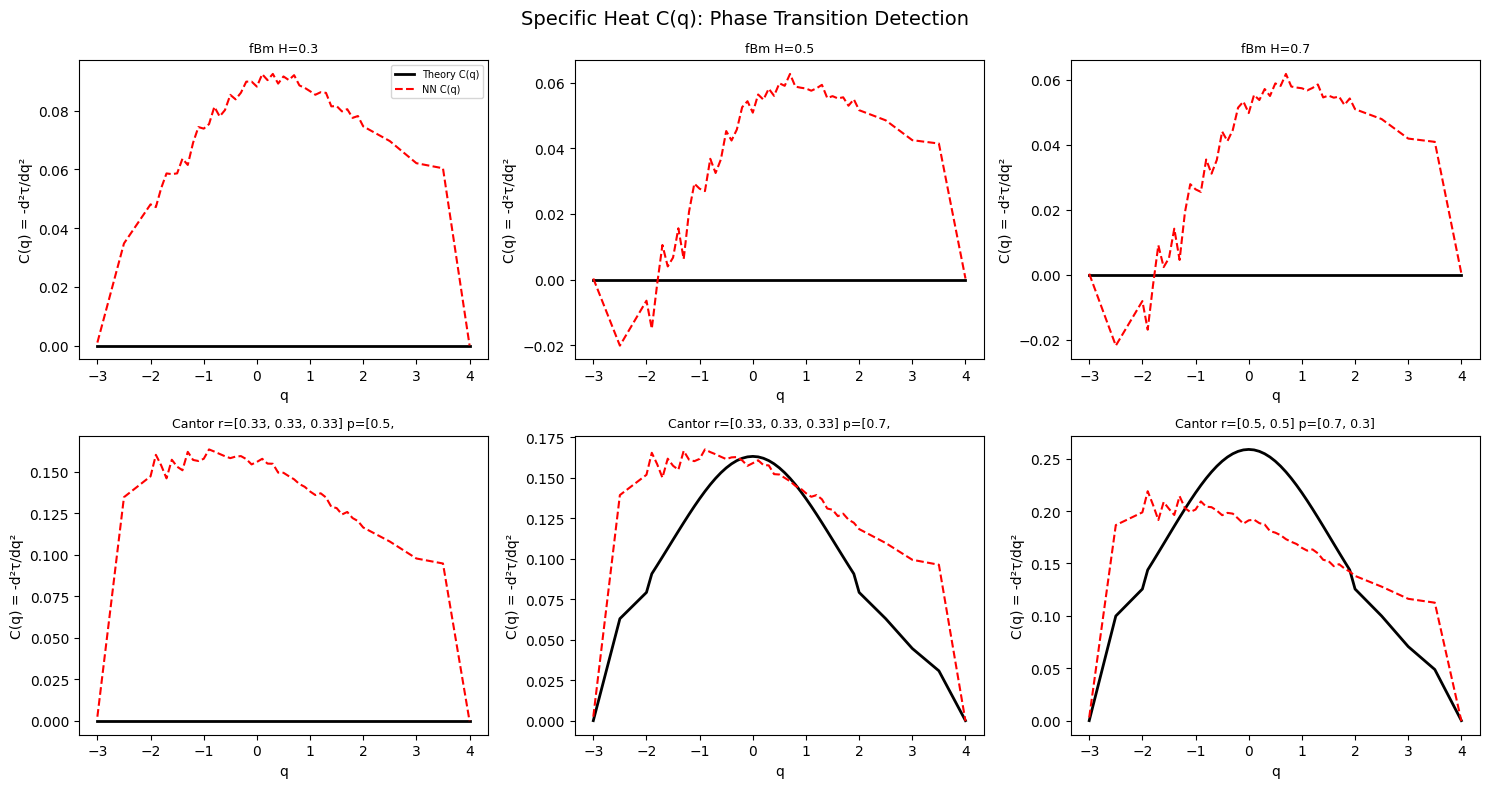

Phase transition detection accuracy: 99.6%
q* estimation MAE: 0.076


In [21]:
# Specific heat comparison: NN-predicted C(q) vs analytical
# Phase transition detection accuracy

# Plot C(q) for signals with and without phase transitions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Pick clean samples (one per signal type)
seen = set()
plot_samples = []
for i, sample in enumerate(dataset):
    name = sample['info']['signal_name']
    if name not in seen and sample['info']['degradation']['noise_type'] == 'none' \
       and sample['info']['degradation']['n_bits'] is None:
        seen.add(name)
        plot_samples.append(i)

for ax_idx in range(min(6, len(plot_samples))):
    row, col = divmod(ax_idx, 3)
    ax = axes[row, col]
    idx = plot_samples[ax_idx]
    sample = dataset[idx]
    
    # Analytical C(q)
    C_theory = sample['labels'].get('C_q', compute_specific_heat(
        sample['labels']['tau_q'], q))
    ax.plot(q, C_theory, 'k-', lw=2, label='Theory C(q)')
    
    # NN-predicted C(q)
    if results.get('heat_predictions') is not None:
        C_nn = results['heat_predictions'][idx]
        ax.plot(q, C_nn, 'r--', lw=1.5, label='NN C(q)')
    
    # Mark phase transition
    has_t = sample['labels'].get('has_transition', False)
    q_star = sample['labels'].get('q_star', np.nan)
    if has_t and np.isfinite(q_star):
        ax.axvline(q_star, color='green', ls=':', lw=1.5, label=f'q*={q_star:.2f}')
    
    # NN-predicted q*
    if results.get('trans_predictions') is not None:
        if results['trans_predictions'][idx, 0] > 0:
            q_star_nn = results['trans_predictions'][idx, 1]
            ax.axvline(q_star_nn, color='red', ls=':', lw=1.5, 
                       label=f'NN q*={q_star_nn:.2f}')
    
    name = sample['info']['signal_name'][:35]
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('q')
    ax.set_ylabel('C(q) = -d²τ/dq²')
    if ax_idx == 0:
        ax.legend(fontsize=7)

for ax_idx in range(min(6, len(plot_samples)), 6):
    row, col = divmod(ax_idx, 3)
    axes[row, col].set_visible(False)

plt.suptitle('Specific Heat C(q): Phase Transition Detection', fontsize=14)
plt.tight_layout()
plt.show()

# Print transition detection accuracy
if 'transition_accuracy' in results['metrics']:
    print(f"Phase transition detection accuracy: "
          f"{results['metrics']['transition_accuracy']:.1%}")
if 'q_star_mae' in results['metrics']:
    print(f"q* estimation MAE: {results['metrics']['q_star_mae']:.3f}")

## 9. Spectrum Width Analysis

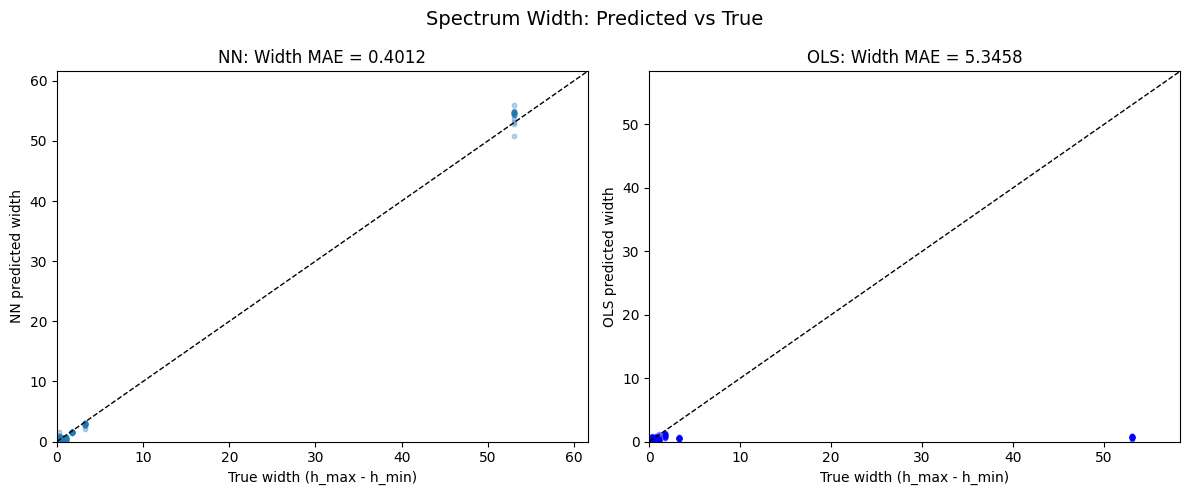

In [22]:
# Scatter plot: predicted vs true spectrum width
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# NN widths
ax = axes[0]
ax.scatter(comp['true_width'], comp['nn_width'], alpha=0.3, s=10)
lims = [0, max(comp['true_width'].max(), comp['nn_width'].max()) * 1.1]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('True width (h_max - h_min)')
ax.set_ylabel('NN predicted width')
ax.set_title(f'NN: Width MAE = {results["metrics"]["width_mae"]:.4f}')
ax.set_xlim(lims)
ax.set_ylim(lims)

# OLS widths (if available)
ax = axes[1]
if comp['ols_width'] is not None:
    ax.scatter(comp['true_width'], comp['ols_width'], alpha=0.3, s=10, c='blue')
    lims_ols = [0, max(comp['true_width'].max(), comp['ols_width'].max()) * 1.1]
    ax.plot(lims_ols, lims_ols, 'k--', lw=1)
    ols_width_mae = np.mean(np.abs(comp['ols_width'] - comp['true_width']))
    ax.set_title(f'OLS: Width MAE = {ols_width_mae:.4f}')
    ax.set_xlim(lims_ols)
    ax.set_ylim(lims_ols)
else:
    ax.text(0.5, 0.5, 'No OLS data', transform=ax.transAxes, ha='center')
ax.set_xlabel('True width (h_max - h_min)')
ax.set_ylabel('OLS predicted width')

plt.suptitle('Spectrum Width: Predicted vs True', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Save Model

In [ ]:
save_model(model, 'wtmm_slope_estimator.safetensors')
print('Model saved to wtmm_slope_estimator.safetensors')

# Reload test
model2 = load_model('wtmm_slope_estimator.safetensors', n_q=n_q, n_scales=n_scales)
print('Model reloaded successfully')